In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from dstapi import DstApi
from scipy import optimize

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.rcParams.update({
    'axes.grid': True,
    'grid.color': 'black',
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})

plt.rcParams.update({'font.size': 14})

In [2]:
#%pip install git+https://github.com/alemartinello/dstapi

# Data Analysis Project

## 1. Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [3]:
# a. setup table
IFOR41 = DstApi('IFOR41')

# b. overview of table
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
# a. set download parameters
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

# b. download data
gini = IFOR41.get_data(params=params)

# c. show first observations
gini.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [5]:
# d. clean data

# replace missing values with NaN
I = gini['INDHOLD'] == '..'
gini.loc[I, 'INDHOLD'] = 'nan'

# convert variable types
gini['TID'] = gini['TID'].astype(int)
gini['INDHOLD'] = gini['INDHOLD'].astype(float)

# drop unnecessary variables
gini = gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

# rename variables
gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

# sort by year
gini = gini.sort_values('year').reset_index(drop=True)

gini.head()

,year,gini
0,1987,22.07
1,1988,22.06
2,1989,21.93
3,1990,22.16
4,1991,21.99


In [6]:
# e. verify data
gini.info()
gini.describe()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    38 non-null     int64  
 1   gini    38 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 740.0 bytes


,year,gini
count,38.000000,38.000000
mean,2005.500000,25.918421
std,11.113055,2.972756
min,1987.000000,21.930000
25%,1996.250000,22.990000
50%,2005.500000,25.970000
75%,2014.750000,28.660000
max,2024.000000,30.610000


In [7]:
gini.tail()

,year,gini
33,2020,29.72
34,2021,30.28
35,2022,29.96
36,2023,30.61
37,2024,30.43


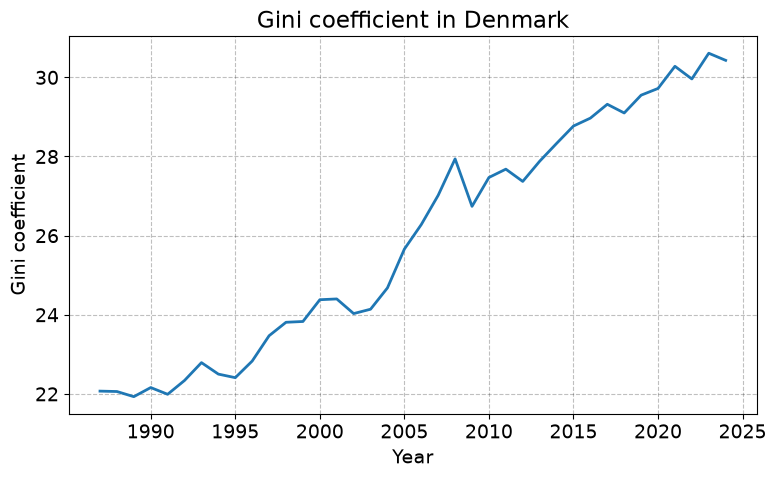

In [8]:
# f. plot Gini coefficient

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

ax.plot(gini['year'], gini['gini'], lw=2)

ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

fig.tight_layout()

In [9]:
# g. setup table for income deciles
IFOR32 = DstApi('IFOR32')

# h. overview of table
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [10]:
# i. set download parameters
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

# j. download data
deciles = IFOR32.get_data(params=params)

# k. show first observations
deciles.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,2013,75704
1,Second decil,All Denmark,2013,140049
2,Third decil,All Denmark,2013,163582
3,Fourth decil,All Denmark,2013,185931
4,Fifth decil,All Denmark,2013,209384


In [11]:
# l. clean decile data

# a. convert variable types
deciles['TID'] = deciles['TID'].astype(int)
deciles['INDHOLD'] = deciles['INDHOLD'].astype(float)

# b. drop unnecessary variable
deciles = deciles.drop(columns=['KOMMUNEDK'])

# c. rename variables
deciles = deciles.rename(columns={
    'DECILGEN': 'decile',
    'TID': 'year',
    'INDHOLD': 'income'
})

# d. sort by year
deciles = deciles.sort_values('year').reset_index(drop=True)

# e. show first observations
deciles.head(10)

,decile,year,income
0,First decil,1987,31418.0
1,Ninth decil,1987,123582.0
2,Eigth decil,1987,110184.0
3,Seventh decil,1987,100691.0
4,Sixth decil,1987,92777.0
5,Fifth decil,1987,85361.0
6,Fourth decil,1987,77577.0
7,Third decil,1987,68786.0
8,Second decil,1987,59014.0
9,Tenth decil,1987,169598.0


In [12]:
# m. verify decile data

deciles.info()
deciles.describe()

print(deciles['decile'].unique())
print(f'Number of observations: {len(deciles)}')

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   decile  380 non-null    str    
 1   year    380 non-null    int64  
 2   income  380 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 13.3 KB
<ArrowStringArray>
[  'First decil',   'Ninth decil',   'Eigth decil', 'Seventh decil',
   'Sixth decil',   'Fifth decil',  'Fourth decil',   'Third decil',
  'Second decil',   'Tenth decil']
Length: 10, dtype: str
Number of observations: 380


In [13]:
# n. calculate top 10 percent income share

# a. calculate total income across deciles within each year
deciles['total_income'] = (
    deciles.groupby('year')['income'].transform('sum')
)

# b. calculate income share for each decile
deciles['income_share'] = (
    deciles['income'] / deciles['total_income']
)

# c. select the tenth decile
I = deciles['decile'] == 'Tenth decil'

top10 = deciles.loc[I, ['year', 'income_share']].copy()

# d. rename variable
top10 = top10.rename(columns={
    'income_share': 'top10_share'
})

# e. convert share to percent
top10['top10_share'] = 100 * top10['top10_share']

# f. sort by year
top10 = top10.sort_values('year').reset_index(drop=True)

top10.head()

,year,top10_share
0,1987,18.454866
1,1988,18.428870
2,1989,18.495170
3,1990,18.641480
4,1991,18.668346


In [14]:
# o. merge inequality measures

# a. merge Gini coefficient and top 10 percent share
inequality = pd.merge(
    gini,
    top10,
    on='year',
    how='inner'
)

# b. show first observations
inequality.head()

,year,gini,top10_share
0,1987,22.07,18.454866
1,1988,22.06,18.428870
2,1989,21.93,18.495170
3,1990,22.16,18.641480
4,1991,21.99,18.668346


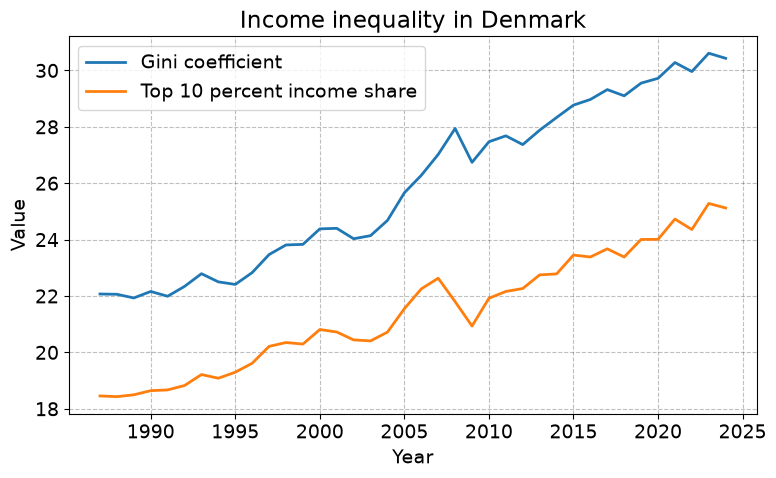

In [15]:
# p. plot inequality measures

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# a. plot both measures
ax.plot(
    inequality['year'],
    inequality['gini'],
    lw=2,
    label='Gini coefficient'
)

ax.plot(
    inequality['year'],
    inequality['top10_share'],
    lw=2,
    label='Top 10 percent income share'
)

# b. labels
ax.set_title('Income inequality in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Value')

# c. legend
ax.legend()

fig.tight_layout()

In [16]:
# q. calculate correlation

corr = inequality['gini'].corr(
    inequality['top10_share']
)

print(f'Correlation between the two inequality measures: {corr:.3f}')

Correlation between the two inequality measures: 0.982


#### Discussion

Income inequality in Denmark has increased substantially since 1987. 
The Gini coefficient increased from approximately 22 in 1987 to above 
30 in 2024. Similarly, the income share of the richest 10 percent 
increased from approximately 18.5 percent to around 25 percent.

The two measures therefore tell a very similar story. Both indicate a 
general increase in income inequality over the period, although there 
are some temporary fluctuations. In particular, both measures decline 
around 2009 before continuing their upward trend.

The correlation between the Gini coefficient and the top 10 percent 
income share is 0.982. This indicates a very strong positive relationship 
between the two measures over time.

### 1.2 Prediction

We fit a linear and a quadratic trend to the Gini coefficient using
least squares. The models are estimated using `scipy.optimize.minimize`
and subsequently checked against `np.polyfit`.

#### 1.2.1 Estimation using scipy.optimize.minimize

In [17]:
# a. prepare data

# number of years since 1987
t = gini['year'].to_numpy() - 1987

# Gini coefficient
y = gini['gini'].to_numpy()

# show first observations
print(t[:5])
print(y[:5])

[0 1 2 3 4]
[22.07 22.06 21.93 22.16 21.99]


In [18]:
# b. define objective function

def objective(beta, t, y):
    """Calculate the sum of squared residuals for a polynomial trend."""
    
    # i. initialize predicted values
    y_hat = np.zeros(len(t))
    
    # ii. calculate polynomial prediction
    for k in range(len(beta)):
        y_hat += beta[k] * t**k
    
    # iii. calculate residuals
    residuals = y - y_hat
    
    # iv. return sum of squared residuals
    return np.sum(residuals**2)

In [19]:
# c. estimate linear and quadratic trends

# a. initial guesses
beta0_linear = np.array([20.0, 0.0])
beta0_quadratic = np.array([20.0, 0.0, 0.0])

# b. estimate linear trend
sol_linear = optimize.minimize(
    objective,
    beta0_linear,
    args=(t, y),
    method='Nelder-Mead'
)

# c. estimate quadratic trend
sol_quadratic = optimize.minimize(
    objective,
    beta0_quadratic,
    args=(t, y),
    method='Nelder-Mead'
)

# d. extract estimated coefficients
beta_linear = sol_linear.x
beta_quadratic = sol_quadratic.x

# e. print results
print('Linear trend:')
print(f'Success: {sol_linear.success}')
print(f'beta0 = {beta_linear[0]:.4f}')
print(f'beta1 = {beta_linear[1]:.4f}')

print('')

print('Quadratic trend:')
print(f'Success: {sol_quadratic.success}')
print(f'beta0 = {beta_quadratic[0]:.4f}')
print(f'beta1 = {beta_quadratic[1]:.4f}')
print(f'beta2 = {beta_quadratic[2]:.6f}')

Linear trend:
Success: True
beta0 = 21.0427
beta1 = 0.2636

Quadratic trend:
Success: True
beta0 = 21.3042
beta1 = 0.2200
beta2 = 0.001178


In [20]:
# d. inspect optimization results

print('Linear trend:')
print(sol_linear.message)

print('')

print('Quadratic trend:')
print(sol_quadratic.message)

Linear trend:
Optimization terminated successfully.

Quadratic trend:
Optimization terminated successfully.


#### 1.2.2 Comparison with np.polyfit

In [21]:
# d. check estimates with np.polyfit

# a. estimate linear trend with np.polyfit
polyfit_linear = np.polyfit(t, y, 1)

# b. estimate quadratic trend with np.polyfit
polyfit_quadratic = np.polyfit(t, y, 2)

# c. reorder coefficients to match our own notation
beta_linear_polyfit = np.array([
    polyfit_linear[1],
    polyfit_linear[0]
])

beta_quadratic_polyfit = np.array([
    polyfit_quadratic[2],
    polyfit_quadratic[1],
    polyfit_quadratic[0]
])

# d. print comparison
print('Linear trend:')
print('Minimize:', beta_linear)
print('Polyfit: ', beta_linear_polyfit)

print('')

print('Quadratic trend:')
print('Minimize:', beta_quadratic)
print('Polyfit: ', beta_quadratic_polyfit)

# e. check whether coefficients are approximately equal
print('')
print('Linear coefficients match:',
      np.allclose(beta_linear, beta_linear_polyfit, atol=1e-4))

print('Quadratic coefficients match:',
      np.allclose(beta_quadratic, beta_quadratic_polyfit, atol=1e-4))

Linear trend:
Minimize: [21.04272868  0.26355106]
Polyfit:  [21.04275304  0.26354962]

Quadratic trend:
Minimize: [2.13041998e+01 2.19977038e-01 1.17760240e-03]
Polyfit:  [2.13042004e+01 2.19975061e-01 1.17769085e-03]

Linear coefficients match: True
Quadratic coefficients match: True


The coefficients obtained with `scipy.optimize.minimize` and `np.polyfit`
are approximately identical for both specifications. This confirms that
our own minimization procedure reproduces the least-squares estimates.

#### 1.2.3 Predictions for 2030 and 2040

In [22]:
# e. predict Gini coefficient in 2030 and 2040

# a. years to predict
future_years = np.array([2030, 2040])

# b. convert calendar years to years since 1987
# 1987 corresponds to t = 0 in our model
t_future = future_years - 1987

# c. predictions from the linear trend
gini_linear_future = (
    beta_linear[0]
    + beta_linear[1] * t_future
)

# d. predictions from the quadratic trend
gini_quadratic_future = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_future
    + beta_quadratic[2] * t_future**2
)

# e. print predictions
for i, year in enumerate(future_years):
    print(f'Year {year}:')
    print(f'Linear prediction = {gini_linear_future[i]:.2f}')
    print(f'Quadratic prediction = {gini_quadratic_future[i]:.2f}')
    print('')

Year 2030:
Linear prediction = 32.38
Quadratic prediction = 32.94

Year 2040:
Linear prediction = 35.01
Quadratic prediction = 36.27



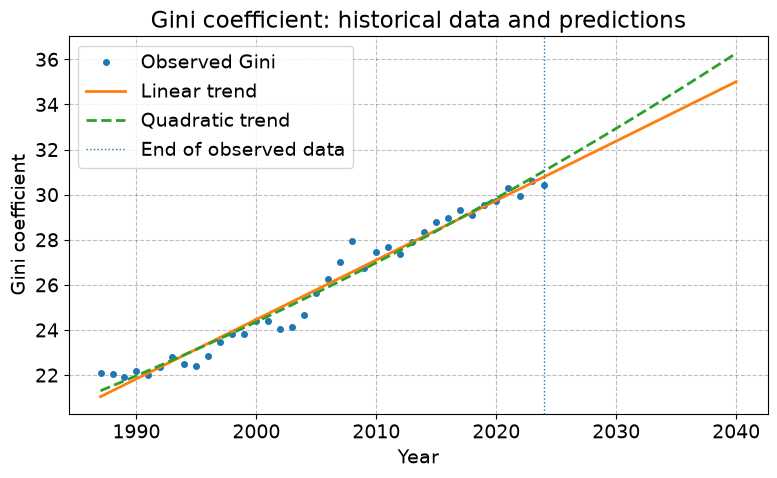

In [23]:
# f. plot historical data and predictions

# a. create years from 1987 to 2040
years_plot = np.arange(1987, 2041)

# b. convert years to years since 1987
t_plot = years_plot - 1987

# c. calculate fitted and predicted values
gini_linear_plot = (
    beta_linear[0]
    + beta_linear[1] * t_plot
)

gini_quadratic_plot = (
    beta_quadratic[0]
    + beta_quadratic[1] * t_plot
    + beta_quadratic[2] * t_plot**2
)

# d. create figure
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# e. plot historical Gini observations
ax.plot(
    gini['year'],
    gini['gini'],
    ls='',
    marker='o',
    markersize=4,
    label='Observed Gini'
)

# f. plot linear trend
ax.plot(
    years_plot,
    gini_linear_plot,
    lw=2,
    label='Linear trend'
)

# g. plot quadratic trend
ax.plot(
    years_plot,
    gini_quadratic_plot,
    lw=2,
    ls='--',
    label='Quadratic trend'
)

# h. indicate where prediction period begins
ax.axvline(
    2024,
    lw=1,
    ls=':',
    label='End of observed data'
)

# i. labels
ax.set_title('Gini coefficient: historical data and predictions')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

# j. legend
ax.legend()

fig.tight_layout()

In [24]:
# g. evaluate historical fit

# a. fitted values for the historical period
gini_linear_fitted = (
    beta_linear[0]
    + beta_linear[1] * t
)

gini_quadratic_fitted = (
    beta_quadratic[0]
    + beta_quadratic[1] * t
    + beta_quadratic[2] * t**2
)

# b. calculate residuals
residuals_linear = y - gini_linear_fitted
residuals_quadratic = y - gini_quadratic_fitted

# c. calculate sum of squared residuals
sse_linear = np.sum(residuals_linear**2)
sse_quadratic = np.sum(residuals_quadratic**2)

# d. calculate root mean squared error
rmse_linear = np.sqrt(np.mean(residuals_linear**2))
rmse_quadratic = np.sqrt(np.mean(residuals_quadratic**2))

# e. print results
print('Historical fit:')
print(f'Linear SSE = {sse_linear:.3f}')
print(f'Quadratic SSE = {sse_quadratic:.3f}')
print('')
print(f'Linear RMSE = {rmse_linear:.3f}')
print(f'Quadratic RMSE = {rmse_quadratic:.3f}')

Historical fit:
Linear SSE = 9.589
Quadratic SSE = 8.981

Linear RMSE = 0.502
Quadratic RMSE = 0.486


#### Discussion

Both the linear and the quadratic trend fit the historical Gini data
reasonably well. The linear model has an RMSE of 0.502, while the
quadratic model has a slightly lower RMSE of 0.486. This suggests that
the quadratic specification provides a marginally better fit to the
historical data.

The two models give relatively similar predictions for 2030. The linear
model predicts a Gini coefficient of 32.38, while the quadratic model
predicts 32.94. The difference is therefore 0.56 Gini points.

By 2040, the predictions differ more. The linear model predicts 35.01,
while the quadratic model predicts 36.27, corresponding to a difference
of 1.26 Gini points. The predictions therefore become more sensitive to
the chosen functional form as the forecast horizon increases.

Neither prediction should be interpreted as a precise forecast of future
inequality. Both models simply extrapolate historical trends and do not
take into account future changes in, for example, taxes, transfers,
labour markets or the broader economy. The quadratic model fits the
historical data slightly better, but its curvature also makes long-run
predictions more sensitive. I would therefore be cautious when using
either model for long-term forecasting.

### 1.3 Municipalities

We now use the municipality-level data to examine differences in income
inequality across Danish municipalities.

#### 1.3.1 Correlation across municipalities

In [25]:
# a. download Gini coefficient for all municipalities

# a. set download parameters
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

# b. download data
gini_municipalities = IFOR41.get_data(params=params)

# c. show first observations
gini_municipalities.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,Copenhagen,2016,33.24
2,Gini coefficient,Frederiksberg,2016,34.85
3,Gini coefficient,Ballerup,2016,25.77
4,Gini coefficient,Brøndby,2016,25.71


In [26]:
# b. clean municipality-level Gini data

# a. replace missing values with NaN
I = gini_municipalities['INDHOLD'] == '..'
gini_municipalities.loc[I, 'INDHOLD'] = 'nan'

# b. convert variable types
gini_municipalities['TID'] = (
    gini_municipalities['TID'].astype(int)
)

gini_municipalities['INDHOLD'] = (
    gini_municipalities['INDHOLD'].astype(float)
)

# c. remove the observation for all of Denmark
I = gini_municipalities['KOMMUNEDK'] != 'All Denmark'
gini_municipalities = gini_municipalities.loc[I].copy()

# d. drop unnecessary variable
gini_municipalities = gini_municipalities.drop(
    columns=['ULLIG']
)

# e. rename variables
gini_municipalities = gini_municipalities.rename(columns={
    'KOMMUNEDK': 'municipality',
    'TID': 'year',
    'INDHOLD': 'gini'
})

# f. sort data
gini_municipalities = (
    gini_municipalities
    .sort_values(['year', 'municipality'])
    .reset_index(drop=True)
)

# g. show first observations
gini_municipalities.head()

,municipality,year,gini
0,Aabenraa,1987,21.33
1,Aalborg,1987,21.01
2,Aarhus,1987,22.10
3,Albertslund,1987,18.82
4,Allerød,1987,19.86


In [27]:
# c. download income deciles for all municipalities

# a. set download parameters
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

# b. download data
deciles_municipalities = IFOR32.get_data(params=params)

# c. show first observations
deciles_municipalities.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Second decil,Odense,2013,123841
1,Third decil,Odense,2013,150153
2,Fourth decil,Odense,2013,170790
3,Fifth decil,Odense,2013,193979
4,Sixth decil,Odense,2013,218942


In [28]:
# d. clean municipality-level decile data

# a. convert variable types
deciles_municipalities['TID'] = (
    deciles_municipalities['TID'].astype(int)
)

deciles_municipalities['INDHOLD'] = (
    deciles_municipalities['INDHOLD'].astype(float)
)

# b. remove observations for all of Denmark
I = deciles_municipalities['KOMMUNEDK'] != 'All Denmark'
deciles_municipalities = deciles_municipalities.loc[I].copy()

# c. rename variables
deciles_municipalities = deciles_municipalities.rename(columns={
    'DECILGEN': 'decile',
    'KOMMUNEDK': 'municipality',
    'TID': 'year',
    'INDHOLD': 'income'
})

# d. sort data
deciles_municipalities = (
    deciles_municipalities
    .sort_values(['year', 'municipality', 'decile'])
    .reset_index(drop=True)
)

# e. show first observations
deciles_municipalities.head(10)

,decile,municipality,year,income
0,Eigth decil,Aabenraa,1987,103934.0
1,Fifth decil,Aabenraa,1987,81428.0
2,First decil,Aabenraa,1987,32392.0
3,Fourth decil,Aabenraa,1987,74363.0
4,Ninth decil,Aabenraa,1987,116181.0
5,Second decil,Aabenraa,1987,57606.0
6,Seventh decil,Aabenraa,1987,95331.0
7,Sixth decil,Aabenraa,1987,88112.0
8,Tenth decil,Aabenraa,1987,160791.0
9,Third decil,Aabenraa,1987,66307.0


In [29]:
# e. calculate top 10 percent income share for each municipality

# a. calculate total income across deciles
# within each municipality and year
deciles_municipalities['total_income'] = (
    deciles_municipalities
    .groupby(['municipality', 'year'])['income']
    .transform('sum')
)

# b. calculate income share for each decile
deciles_municipalities['income_share'] = (
    deciles_municipalities['income']
    / deciles_municipalities['total_income']
)

# c. select the tenth decile
I = deciles_municipalities['decile'] == 'Tenth decil'

top10_municipalities = (
    deciles_municipalities
    .loc[I, ['municipality', 'year', 'income_share']]
    .copy()
)

# d. rename variable
top10_municipalities = top10_municipalities.rename(columns={
    'income_share': 'top10_share'
})

# e. convert share to percent
top10_municipalities['top10_share'] = (
    100 * top10_municipalities['top10_share']
)

# f. sort data
top10_municipalities = (
    top10_municipalities
    .sort_values(['year', 'municipality'])
    .reset_index(drop=True)
)

# g. show first observations
top10_municipalities.head()

,municipality,year,top10_share
0,Aabenraa,1987,18.345817
1,Aalborg,1987,17.816782
2,Aarhus,1987,18.405992
3,Albertslund,1987,16.735177
4,Allerød,1987,17.940579


In [30]:
# f. merge municipality-level inequality measures

# a. merge Gini coefficient and top 10 percent share
inequality_municipalities = pd.merge(
    gini_municipalities,
    top10_municipalities,
    on=['municipality', 'year'],
    how='inner'
)

# b. show first observations
inequality_municipalities.head()

,municipality,year,gini,top10_share
0,Aabenraa,1987,21.33,18.345817
1,Aalborg,1987,21.01,17.816782
2,Aarhus,1987,22.10,18.405992
3,Albertslund,1987,18.82,16.735177
4,Allerød,1987,19.86,17.940579


In [31]:
# g. calculate correlation across municipalities

# a. find the most recent year
latest_year = inequality_municipalities['year'].max()

# b. select observations from the most recent year
I = inequality_municipalities['year'] == latest_year

inequality_latest = (
    inequality_municipalities
    .loc[I]
    .copy()
)

# c. calculate correlation across municipalities
corr_municipalities = inequality_latest['gini'].corr(
    inequality_latest['top10_share']
)

# d. print result
print(f'Most recent year: {latest_year}')
print(
    f'Correlation across municipalities: '
    f'{corr_municipalities:.3f}'
)

Most recent year: 2024
Correlation across municipalities: 0.975


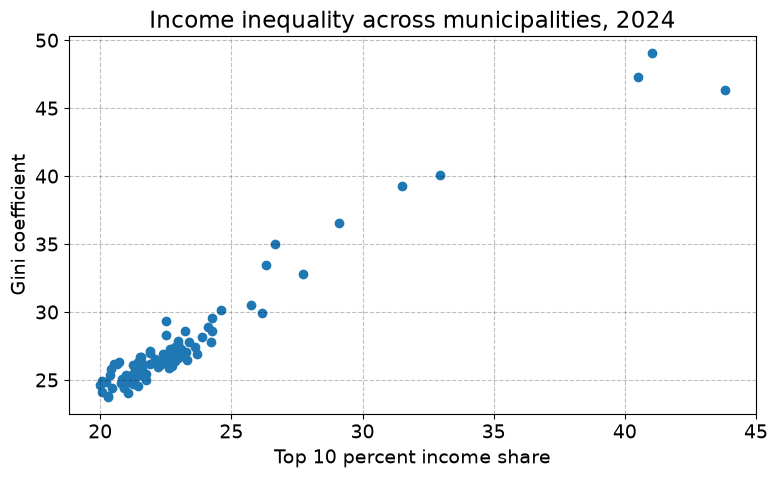

In [32]:
# h. plot Gini coefficient against top 10 percent share

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# a. scatter plot
ax.scatter(
    inequality_latest['top10_share'],
    inequality_latest['gini']
)

# b. labels
ax.set_title(
    f'Income inequality across municipalities, {latest_year}'
)
ax.set_xlabel('Top 10 percent income share')
ax.set_ylabel('Gini coefficient')

fig.tight_layout()

#### Conclusion

The correlation between the Gini coefficient and the top 10 percent
income share across municipalities in 2024 is 0.975. This is very close
to the correlation of 0.982 found over time for Denmark as a whole.

The scatter plot also shows a strong positive relationship between the
two measures. Municipalities with a higher top 10 percent income share
generally also have a higher Gini coefficient. This suggests that the
two measures capture similar differences in income inequality across
municipalities.

#### 1.3.2 Most and least unequal municipalities

In [33]:
# a. identify the most and least unequal municipalities

# a. find the most recent year
latest_year = gini_municipalities['year'].max()

# b. select Gini observations from the most recent year
I = gini_municipalities['year'] == latest_year

gini_latest = (
    gini_municipalities
    .loc[I, ['municipality', 'gini']]
    .dropna()
    .copy()
)

# c. find the 10 most unequal municipalities
most_unequal = (
    gini_latest
    .nlargest(10, 'gini')
    .reset_index(drop=True)
)

# d. find the 10 least unequal municipalities
least_unequal = (
    gini_latest
    .nsmallest(10, 'gini')
    .sort_values('gini')
    .reset_index(drop=True)
)

# e. show rankings
print(f'Most unequal municipalities in {latest_year}:')
print(most_unequal)

print('')

print(f'Least unequal municipalities in {latest_year}:')
print(least_unequal)

Most unequal municipalities in 2024:
     municipality   gini
0        Gentofte  49.04
1       Rudersdal  47.31
2           Vejen  46.32
3        Hørsholm  40.07
4  Lyngby-Taarbæk  39.28
5   Frederiksberg  36.54
6      Copenhagen  34.97
7          Aarhus  33.43
8     Fredensborg  32.76
9       Helsingør  30.55

Least unequal municipalities in 2024:
      municipality   gini
0  Faaborg-Midtfyn  23.77
1           Egedal  23.85
2         Bornholm  24.03
3             Faxe  24.09
4         Favrskov  24.41
5          Halsnæs  24.41
6           Assens  24.46
7        Hedensted  24.58
8      Albertslund  24.66
9            Odder  24.70


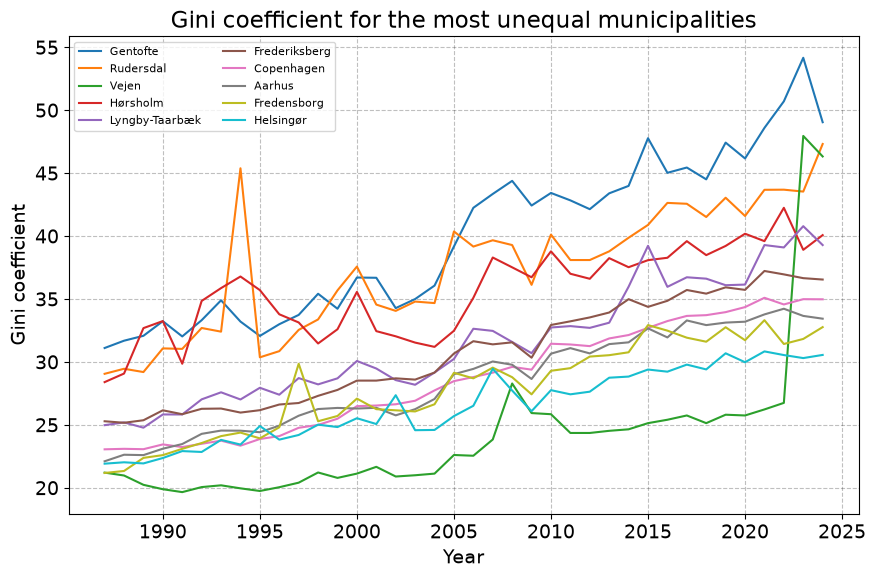

In [34]:
# b. inspect underlying series for the most unequal municipalities

# a. store municipality names
most_unequal_names = most_unequal['municipality'].tolist()

# b. select historical observations
I = gini_municipalities['municipality'].isin(most_unequal_names)

most_unequal_series = (
    gini_municipalities
    .loc[I]
    .copy()
)

# c. plot historical Gini series
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)

for municipality in most_unequal_names:
    
    I = most_unequal_series['municipality'] == municipality
    
    municipality_data = (
        most_unequal_series
        .loc[I]
        .sort_values('year')
    )
    
    ax.plot(
        municipality_data['year'],
        municipality_data['gini'],
        lw=1.5,
        label=municipality
    )

# d. labels
ax.set_title('Gini coefficient for the most unequal municipalities')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

# e. legend
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()

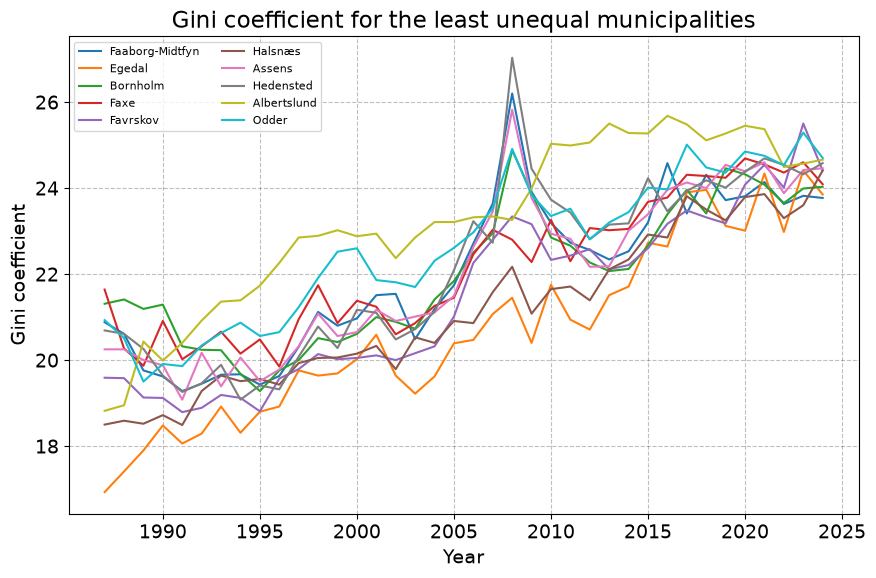

In [35]:
# c. inspect underlying series for the least unequal municipalities

# a. store municipality names
least_unequal_names = least_unequal['municipality'].tolist()

# b. select historical observations
I = gini_municipalities['municipality'].isin(least_unequal_names)

least_unequal_series = (
    gini_municipalities
    .loc[I]
    .copy()
)

# c. plot historical Gini series
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)

for municipality in least_unequal_names:
    
    I = least_unequal_series['municipality'] == municipality
    
    municipality_data = (
        least_unequal_series
        .loc[I]
        .sort_values('year')
    )
    
    ax.plot(
        municipality_data['year'],
        municipality_data['gini'],
        lw=1.5,
        label=municipality
    )

# d. labels
ax.set_title('Gini coefficient for the least unequal municipalities')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

# e. legend
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()

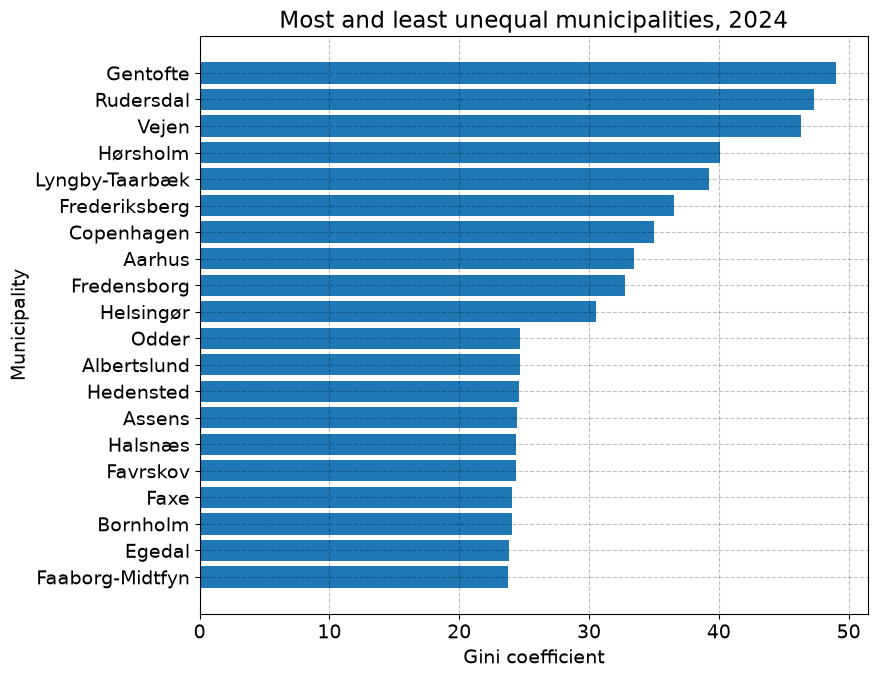

In [36]:
# d. illustrate most and least unequal municipalities

# a. combine the two rankings
inequality_ranking = pd.concat(
    [
        least_unequal,
        most_unequal
    ],
    ignore_index=True
)

# b. sort municipalities by Gini coefficient
inequality_ranking = (
    inequality_ranking
    .sort_values('gini')
    .reset_index(drop=True)
)

# c. create figure
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(1,1,1)

# d. horizontal bar chart
ax.barh(
    inequality_ranking['municipality'],
    inequality_ranking['gini']
)

# e. labels
ax.set_title(
    f'Most and least unequal municipalities, {latest_year}'
)
ax.set_xlabel('Gini coefficient')
ax.set_ylabel('Municipality')

fig.tight_layout()

#### Conclusion

There are substantial differences in income inequality across Danish
municipalities in 2024. Gentofte has the highest Gini coefficient at
49.04, followed by Rudersdal and Vejen. In contrast, Faaborg-Midtfyn has
the lowest Gini coefficient at 23.77.

The underlying time series show that several of the highly ranked
municipalities, including Gentofte, Rudersdal, Hørsholm and
Lyngby-Taarbæk, have had relatively high Gini coefficients for a longer
period. Their position in the ranking therefore does not appear to be
driven only by a single observation.

Vejen is an important exception. Its Gini coefficient increases very
sharply in the final years of the sample after being considerably lower
through most of the historical period. In light of the warning about
small populations and very large individual incomes, its high ranking
should therefore be interpreted with particular caution.

The least unequal municipalities are much more closely clustered, and
their historical series are generally less extreme. Overall, the
dispersion in inequality is therefore considerably larger among the
municipalities at the top of the ranking than among those at the bottom.

#### 1.3.3 Largest and smallest changes in the Gini coefficient

In [37]:
# a. calculate changes in the Gini coefficient

# a. find first and most recent year
first_year = gini_municipalities['year'].min()
latest_year = gini_municipalities['year'].max()

# b. select observations from the first year
I = gini_municipalities['year'] == first_year

gini_first = (
    gini_municipalities
    .loc[I, ['municipality', 'gini']]
    .rename(columns={'gini': 'gini_first'})
    .copy()
)

# c. select observations from the most recent year
I = gini_municipalities['year'] == latest_year

gini_last = (
    gini_municipalities
    .loc[I, ['municipality', 'gini']]
    .rename(columns={'gini': 'gini_last'})
    .copy()
)

# d. merge first and last observations
gini_change = pd.merge(
    gini_first,
    gini_last,
    on='municipality',
    how='inner'
)

# e. calculate change in the Gini coefficient
gini_change['change'] = (
    gini_change['gini_last']
    - gini_change['gini_first']
)

# f. show first observations
gini_change.head()

,municipality,gini_first,gini_last,change
0,Aabenraa,21.33,28.14,6.81
1,Aalborg,21.01,28.59,7.58
2,Aarhus,22.10,33.43,11.33
3,Albertslund,18.82,24.66,5.84
4,Allerød,19.86,27.29,7.43


In [38]:
# b. identify municipalities with largest and smallest changes

# a. find the 10 largest increases
largest_changes = (
    gini_change
    .nlargest(10, 'change')
    .reset_index(drop=True)
)

# b. find the 10 smallest changes
smallest_changes = (
    gini_change
    .nsmallest(10, 'change')
    .reset_index(drop=True)
)

# c. show rankings
print(
    f'Largest changes from {first_year} to {latest_year}:'
)
print(largest_changes)

print('')

print(
    f'Smallest changes from {first_year} to {latest_year}:'
)
print(smallest_changes)

Largest changes from 1987 to 2024:
     municipality  gini_first  gini_last  change
0           Vejen       21.20      46.32   25.12
1       Rudersdal       29.05      47.31   18.26
2        Gentofte       31.10      49.04   17.94
3  Lyngby-Taarbæk       24.97      39.28   14.31
4      Copenhagen       23.05      34.97   11.92
5        Hørsholm       28.39      40.07   11.68
6     Fredensborg       21.17      32.76   11.59
7          Aarhus       22.10      33.43   11.33
8   Frederiksberg       25.28      36.54   11.26
9      Vallensbæk       15.90      26.70   10.80

Smallest changes from 1987 to 2024:
      municipality  gini_first  gini_last  change
0             Fanø       25.67      26.34    0.67
1              Ærø       24.63      26.98    2.35
2             Faxe       21.64      24.09    2.45
3             Læsø       22.81      25.41    2.60
4         Bornholm       21.31      24.03    2.72
5  Faaborg-Midtfyn       20.88      23.77    2.89
6             Sorø       22.24      25.

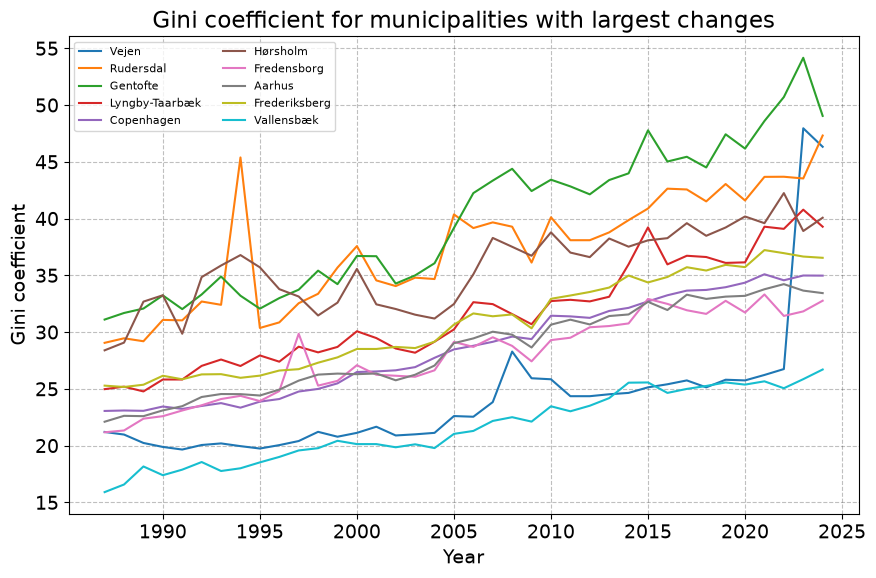

In [39]:
# c. inspect underlying series for municipalities
# with the largest changes

# a. store municipality names
largest_change_names = largest_changes['municipality'].tolist()

# b. select historical observations
I = gini_municipalities['municipality'].isin(
    largest_change_names
)

largest_change_series = (
    gini_municipalities
    .loc[I]
    .copy()
)

# c. plot historical Gini series
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)

for municipality in largest_change_names:
    
    I = (
        largest_change_series['municipality']
        == municipality
    )
    
    municipality_data = (
        largest_change_series
        .loc[I]
        .sort_values('year')
    )
    
    ax.plot(
        municipality_data['year'],
        municipality_data['gini'],
        lw=1.5,
        label=municipality
    )

# d. labels
ax.set_title(
    'Gini coefficient for municipalities with largest changes'
)
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

# e. legend
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()

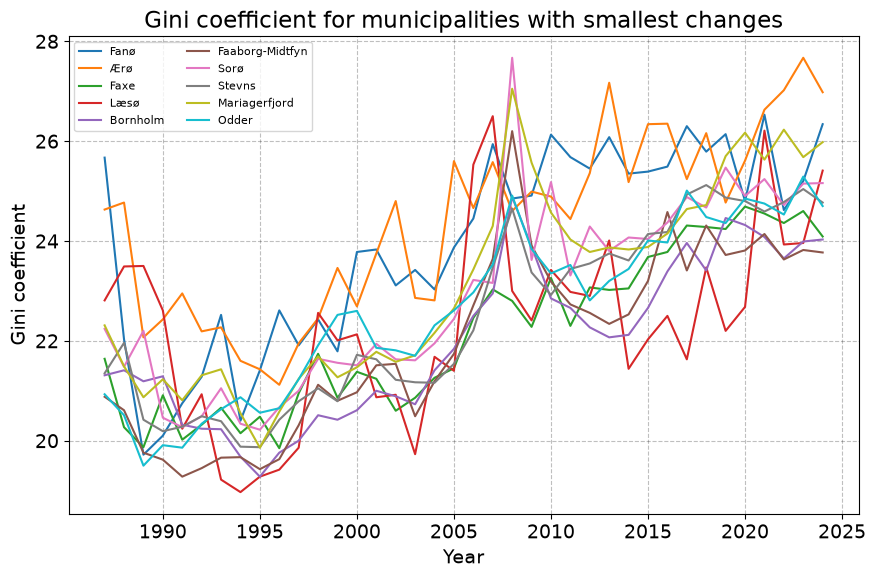

In [40]:
# d. inspect underlying series for municipalities
# with the smallest changes

# a. store municipality names
smallest_change_names = smallest_changes['municipality'].tolist()

# b. select historical observations
I = gini_municipalities['municipality'].isin(
    smallest_change_names
)

smallest_change_series = (
    gini_municipalities
    .loc[I]
    .copy()
)

# c. plot historical Gini series
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)

for municipality in smallest_change_names:
    
    I = (
        smallest_change_series['municipality']
        == municipality
    )
    
    municipality_data = (
        smallest_change_series
        .loc[I]
        .sort_values('year')
    )
    
    ax.plot(
        municipality_data['year'],
        municipality_data['gini'],
        lw=1.5,
        label=municipality
    )

# d. labels
ax.set_title(
    'Gini coefficient for municipalities with smallest changes'
)
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

# e. legend
ax.legend(fontsize=8, ncol=2)

fig.tight_layout()

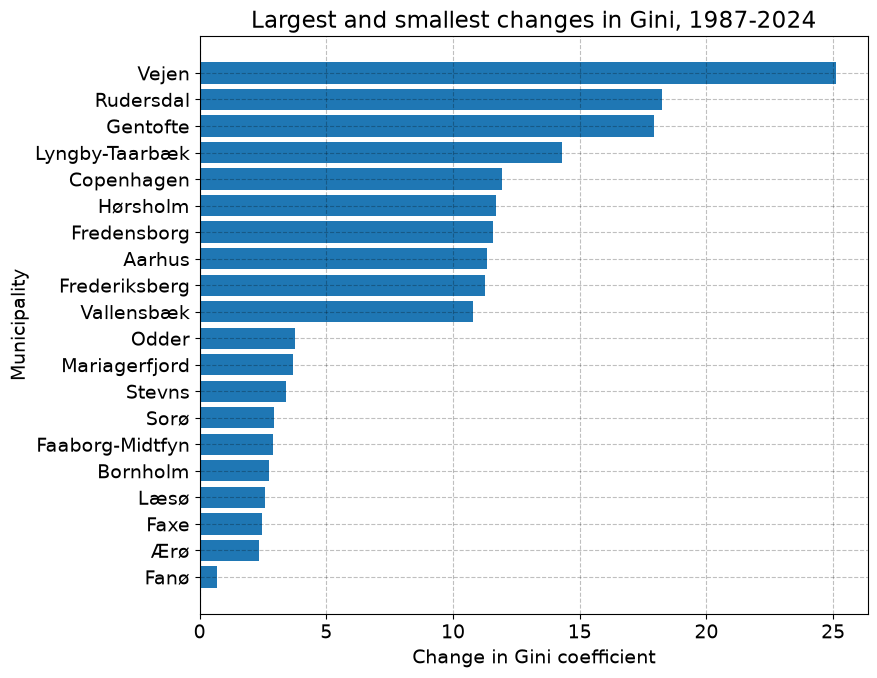

In [41]:
# e. illustrate largest and smallest changes

# a. combine municipalities
change_ranking = pd.concat(
    [
        smallest_changes,
        largest_changes
    ],
    ignore_index=True
)

# b. sort by change in Gini coefficient
change_ranking = (
    change_ranking
    .sort_values('change')
    .reset_index(drop=True)
)

# c. create figure
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(1,1,1)

# d. horizontal bar chart
ax.barh(
    change_ranking['municipality'],
    change_ranking['change']
)

# e. labels
ax.set_title(
    f'Largest and smallest changes in Gini, '
    f'{first_year}-{latest_year}'
)
ax.set_xlabel('Change in Gini coefficient')
ax.set_ylabel('Municipality')

fig.tight_layout()

#### Conclusion

The change in the Gini coefficient varies substantially across
municipalities between 1987 and 2024. Vejen has the largest measured
increase, with a rise of 25.12 Gini points, followed by Rudersdal and
Gentofte.

However, the underlying time series show that Vejen's result is largely
driven by a very sharp increase at the end of the sample. Its ranking
should therefore be interpreted with caution. In contrast, the increases
in municipalities such as Gentofte and Rudersdal appear to reflect a more
persistent rise in inequality over time.

The municipalities with the smallest changes have also generally
experienced increasing inequality, but by much less. Fanø has the
smallest increase, with the Gini coefficient rising by only 0.67 points
between 1987 and 2024.

Overall, the results show considerable heterogeneity in how income
inequality has developed across municipalities. The underlying time
series are important for distinguishing persistent changes from changes
that may be driven by unusually large observations in individual years.

### 1.4 Extension

We examine whether differences in educational attainment across
municipalities are related to differences in income inequality.

#### 1.4.1 Educational attainment across municipalities

In [42]:
# a. setup education table

HFUDD11 = DstApi('HFUDD11')

# b. overview of table
HFUDD11.tablesummary(language='en')

Table HFUDD11: Educational attainment (15-69 years) by region, ancestry, highest education completed, age, sex and time
Last update: 2026-04-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,BOPOMR,105,000,All Denmark,851,Aalborg,False
1,HERKOMST,4,TOT,Total,3,Descendant,False
2,HFUDD,93,TOT,Total,H9099,H9099 Not stated,False
3,ALDER,12,TOT,"Age, total",65-69,65-69 years,False
4,KØN,3,TOT,Total,K,Women,False
5,Tid,18,2008,2008,2025,2025,True


In [43]:
# c. inspect education and age categories

# a. show education categories
education_levels = HFUDD11.variable_levels(
    'HFUDD',
    language='en'
)

education_levels

,id,text
0,TOT,Total
1,H10,H10 Primary education
2,H1001,H1001 No education
3,H1010,H1010 Primary school through to 6th grade
4,H1020,H1020 Primary school 7th-9th grade
...,...,...
88,H8080,"H8080 Agriculture, nature and environment, PhD"
89,H8090,"H8090 Health science, PhD"
90,H8097,"H8097 Higher education not specified, PhD"
91,H90,H90 Not stated


In [44]:
# d. inspect age categories

age_levels = HFUDD11.variable_levels(
    'ALDER',
    language='en'
)

age_levels

,id,text
0,TOT,"Age, total"
1,15-19,15-19 years
2,20-24,20-24 years
3,25-29,25-29 years
4,30-34,30-34 years
5,35-39,35-39 years
6,40-44,40-44 years
7,45-49,45-49 years
8,50-54,50-54 years
9,55-59,55-59 years


In [45]:
# e. inspect ancestry and sex categories

ancestry_levels = HFUDD11.variable_levels(
    'HERKOMST',
    language='en'
)

sex_levels = HFUDD11.variable_levels(
    'KØN',
    language='en'
)

print(ancestry_levels)
print('')
print(sex_levels)

    id                      text
0  TOT                     Total
1    5  Persons of Danish origin
2    4                Immigrants
3    3                Descendant

    id   text
0  TOT  Total
1    M    Men
2    K  Women


In [46]:
# f. inspect broad education categories

# a. select broad education categories
broad_education_levels = education_levels[
    education_levels['id'].str.len() <= 3
].copy()

# b. show categories
broad_education_levels

,id,text
0,TOT,Total
1,H10,H10 Primary education
6,H20,H20 Upper secondary education
10,H30,H30 Vocational Education and Training (VET)
26,H35,H35 Qualifying educational programs
30,H40,H40 Short cycle higher education
43,H50,H50 Vocational bachelors educations
58,H60,H60 Bachelors programs
69,H70,H70 Masters programs
81,H80,H80 PhD programs


We use municipality-level education data from Statistics Denmark to examine
whether differences in educational attainment are related to income inequality.

To make municipalities comparable, we focus on individuals aged 30–69 in
2024 and include both sexes and all ancestry groups. We use broad education
categories rather than detailed fields of study.

For each municipality, we calculate the share of the population aged 30–69
in each education category. These shares can then be merged with the Gini
coefficient and used to examine the relationship between educational
attainment and income inequality across municipalities.

In [47]:
# g. download education data for municipalities

# a. define education categories
education_codes = [
    'TOT',
    'H10',
    'H20',
    'H30',
    'H40',
    'H50',
    'H60',
    'H70',
    'H80'
]

# b. define age groups from 30 to 69 years
age_codes = [
    '30-34',
    '35-39',
    '40-44',
    '45-49',
    '50-54',
    '55-59',
    '60-64',
    '65-69'
]

# c. set download parameters
params = {
    'table': 'HFUDD11',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'BOPOMR', 'values': ['*']},
        {'code': 'HERKOMST', 'values': ['TOT']},
        {'code': 'HFUDD', 'values': education_codes},
        {'code': 'ALDER', 'values': age_codes},
        {'code': 'KØN', 'values': ['TOT']},
        {'code': 'Tid', 'values': ['2024']}
    ]
}

# d. download data
education = HFUDD11.get_data(params=params)

# e. show first observations
education.head()

,BOPOMR,HERKOMST,HFUDD,ALDER,KØN,TID,INDHOLD
0,All Denmark,Total,H10 Primary education,30-34 years,Total,2024,51484
1,All Denmark,Total,H10 Primary education,35-39 years,Total,2024,48924
2,All Denmark,Total,H10 Primary education,40-44 years,Total,2024,46951
3,All Denmark,Total,H10 Primary education,45-49 years,Total,2024,51738
4,All Denmark,Total,H10 Primary education,50-54 years,Total,2024,61842


In [48]:
# h. clean municipality-level education data

# a. convert variable types
education['TID'] = education['TID'].astype(int)
education['INDHOLD'] = education['INDHOLD'].astype(float)

# b. remove observations for all of Denmark
I = education['BOPOMR'] != 'All Denmark'
education = education.loc[I].copy()

# c. drop variables that are constant in our sample
education = education.drop(
    columns=['HERKOMST', 'KØN']
)

# d. rename variables
education = education.rename(columns={
    'BOPOMR': 'municipality',
    'HFUDD': 'education',
    'ALDER': 'age',
    'TID': 'year',
    'INDHOLD': 'persons'
})

# e. sort data
education = (
    education
    .sort_values(['municipality', 'education', 'age'])
    .reset_index(drop=True)
)

# f. show first observations
education.head(10)

,municipality,education,age,year,persons
0,Aabenraa,H10 Primary education,30-34 years,2024,534.0
1,Aabenraa,H10 Primary education,35-39 years,2024,497.0
2,Aabenraa,H10 Primary education,40-44 years,2024,538.0
3,Aabenraa,H10 Primary education,45-49 years,2024,555.0
4,Aabenraa,H10 Primary education,50-54 years,2024,699.0
5,Aabenraa,H10 Primary education,55-59 years,2024,769.0
6,Aabenraa,H10 Primary education,60-64 years,2024,918.0
7,Aabenraa,H10 Primary education,65-69 years,2024,1279.0
8,Aabenraa,H20 Upper secondary education,30-34 years,2024,204.0
9,Aabenraa,H20 Upper secondary education,35-39 years,2024,158.0


In [49]:
# i. aggregate education data across age groups

# a. sum persons aged 30-69 within each municipality
# and education category
education_aggregated = (
    education
    .groupby(
        ['municipality', 'year', 'education'],
        as_index=False
    )['persons']
    .sum()
)

# b. show first observations
education_aggregated.head(10)

,municipality,year,education,persons
0,Aabenraa,2024,H10 Primary education,5789.0
1,Aabenraa,2024,H20 Upper secondary education,1264.0
2,Aabenraa,2024,H30 Vocational Education and Training (VET),13223.0
3,Aabenraa,2024,H40 Short cycle higher education,1739.0
4,Aabenraa,2024,H50 Vocational bachelors educations,4927.0
5,Aabenraa,2024,H60 Bachelors programs,326.0
6,Aabenraa,2024,H70 Masters programs,1827.0
7,Aabenraa,2024,H80 PhD programs,144.0
8,Aabenraa,2024,Total,29761.0
9,Aalborg,2024,H10 Primary education,15546.0


In [50]:
# j. calculate education shares

# a. select total population aged 30-69
I = education_aggregated['education'] == 'Total'

education_total = (
    education_aggregated
    .loc[I, ['municipality', 'year', 'persons']]
    .rename(columns={'persons': 'total_persons'})
    .copy()
)

# b. remove total category from education groups
I = education_aggregated['education'] != 'Total'

education_shares = (
    education_aggregated
    .loc[I]
    .copy()
)

# c. merge with total population
education_shares = pd.merge(
    education_shares,
    education_total,
    on=['municipality', 'year'],
    how='inner'
)

# d. calculate share of population in each education category
education_shares['share'] = (
    100
    * education_shares['persons']
    / education_shares['total_persons']
)

# e. show first observations
education_shares.head(10)

,municipality,year,education,persons,total_persons,share
0,Aabenraa,2024,H10 Primary education,5789.0,29761.0,19.451631
1,Aabenraa,2024,H20 Upper secondary education,1264.0,29761.0,4.247169
2,Aabenraa,2024,H30 Vocational Education and Training (VET),13223.0,29761.0,44.430631
3,Aabenraa,2024,H40 Short cycle higher education,1739.0,29761.0,5.843218
4,Aabenraa,2024,H50 Vocational bachelors educations,4927.0,29761.0,16.555223
5,Aabenraa,2024,H60 Bachelors programs,326.0,29761.0,1.095393
6,Aabenraa,2024,H70 Masters programs,1827.0,29761.0,6.138907
7,Aabenraa,2024,H80 PhD programs,144.0,29761.0,0.483855
8,Aalborg,2024,H10 Primary education,15546.0,104604.0,14.861764
9,Aalborg,2024,H20 Upper secondary education,4675.0,104604.0,4.469236


#### 1.4.2 Education and income inequality

We now relate the education shares to the Gini coefficient across
municipalities in 2024. First, we reshape the education data so that
each municipality is represented by one observation with separate
variables for each education category. We then merge these data with
the municipality-level Gini coefficient.

In [51]:
# k. reshape education shares

# a. create shorter names for education categories
education_names = {
    'H10 Primary education': 'primary',
    'H20 Upper secondary education': 'upper_secondary',
    'H30 Vocational Education and Training (VET)': 'vocational',
    'H40 Short cycle higher education': 'short_higher',
    'H50 Vocational bachelors educations': 'vocational_bachelor',
    'H60 Bachelors programs': 'bachelor',
    'H70 Masters programs': 'masters',
    'H80 PhD programs': 'phd'
}

# b. replace education labels with shorter names
education_shares['education'] = (
    education_shares['education']
    .replace(education_names)
)

# c. reshape data from long to wide format
education_wide = (
    education_shares
    .pivot(
        index=['municipality', 'year'],
        columns='education',
        values='share'
    )
    .reset_index()
)

# d. remove column name created by pivot
education_wide.columns.name = None

# e. show first observations
education_wide.head()

,municipality,year,bachelor,masters,phd,primary,short_higher,upper_secondary,vocational,vocational_bachelor
0,Aabenraa,2024,1.095393,6.138907,0.483855,19.451631,5.843218,4.247169,44.430631,16.555223
1,Aalborg,2024,2.268556,15.978356,1.655768,14.861764,6.131697,4.469236,32.726282,20.613934
2,Aarhus,2024,3.033918,23.455816,3.388762,12.314319,6.051930,5.944253,22.374153,22.119644
3,Albertslund,2024,2.057705,10.012674,0.991575,23.208827,5.688511,6.434057,31.186163,18.332961
4,Allerød,2024,2.314850,26.356003,3.623572,7.859899,7.254709,5.847644,24.495045,21.401014


In [52]:
# l. merge education shares with Gini coefficient

# a. select Gini coefficient for 2024
I = gini_municipalities['year'] == 2024

gini_2024 = (
    gini_municipalities
    .loc[I, ['municipality', 'gini']]
    .copy()
)

# b. merge education and inequality data
education_inequality = pd.merge(
    education_wide,
    gini_2024,
    on='municipality',
    how='inner'
)

# c. show first observations
education_inequality.head()

,municipality,year,bachelor,masters,phd,primary,short_higher,upper_secondary,vocational,vocational_bachelor,gini
0,Aabenraa,2024,1.095393,6.138907,0.483855,19.451631,5.843218,4.247169,44.430631,16.555223,28.14
1,Aalborg,2024,2.268556,15.978356,1.655768,14.861764,6.131697,4.469236,32.726282,20.613934,28.59
2,Aarhus,2024,3.033918,23.455816,3.388762,12.314319,6.051930,5.944253,22.374153,22.119644,33.43
3,Albertslund,2024,2.057705,10.012674,0.991575,23.208827,5.688511,6.434057,31.186163,18.332961,24.66
4,Allerød,2024,2.314850,26.356003,3.623572,7.859899,7.254709,5.847644,24.495045,21.401014,27.29


In [53]:
# m. calculate correlations with the Gini coefficient

# a. education variables
education_variables = [
    'primary',
    'upper_secondary',
    'vocational',
    'short_higher',
    'vocational_bachelor',
    'bachelor',
    'masters',
    'phd'
]

# b. calculate correlation for each education category
correlations = []

for variable in education_variables:
    
    corr = education_inequality[variable].corr(
        education_inequality['gini']
    )
    
    correlations.append({
        'education': variable,
        'correlation': corr
    })

# c. convert results to DataFrame
education_correlations = pd.DataFrame(correlations)

# d. sort by correlation
education_correlations = (
    education_correlations
    .sort_values('correlation')
    .reset_index(drop=True)
)

education_correlations

,education,correlation
0,vocational,-0.607270
1,primary,-0.496684
2,short_higher,-0.146837
3,vocational_bachelor,0.058769
4,upper_secondary,0.464640
5,bachelor,0.578871
6,phd,0.658189
7,masters,0.679114


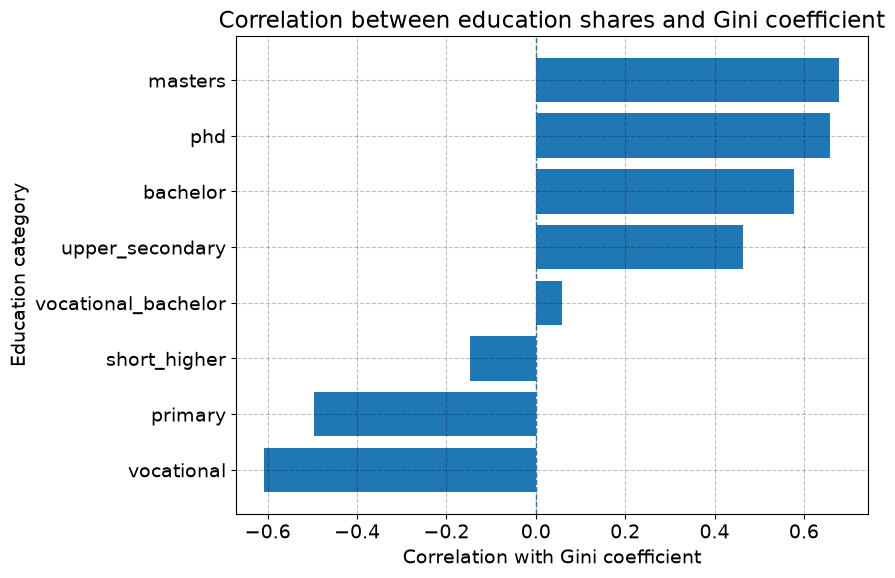

In [54]:
# n. illustrate correlations between education and inequality

# a. create figure
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)

# b. horizontal bar chart
ax.barh(
    education_correlations['education'],
    education_correlations['correlation']
)

# c. add vertical line at zero
ax.axvline(
    0,
    lw=1,
    ls='--'
)

# d. labels
ax.set_title(
    'Correlation between education shares and Gini coefficient'
)
ax.set_xlabel('Correlation with Gini coefficient')
ax.set_ylabel('Education category')

fig.tight_layout()

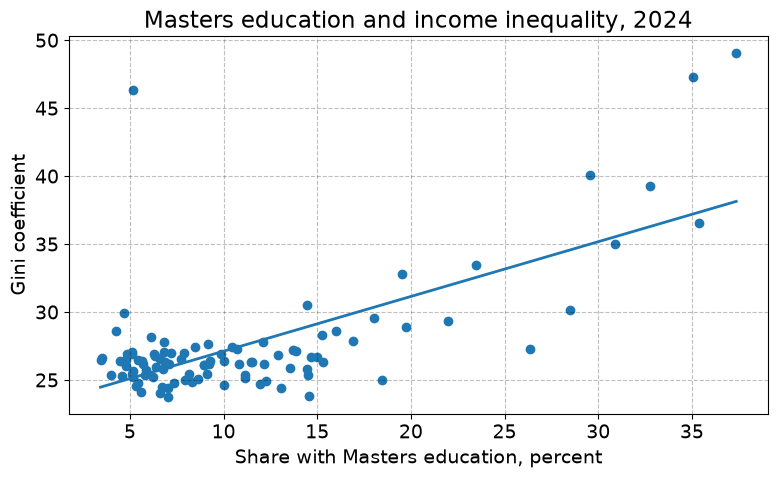

In [55]:
# o. plot Masters share against Gini coefficient

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# a. scatter plot
ax.scatter(
    education_inequality['masters'],
    education_inequality['gini']
)

# b. estimate linear trend
beta = np.polyfit(
    education_inequality['masters'],
    education_inequality['gini'],
    1
)

# c. create values for fitted line
x = np.linspace(
    education_inequality['masters'].min(),
    education_inequality['masters'].max(),
    100
)

y_hat = beta[0] * x + beta[1]

# d. plot fitted line
ax.plot(
    x,
    y_hat,
    lw=2
)

# e. labels
ax.set_title('Masters education and income inequality, 2024')
ax.set_xlabel('Share with Masters education, percent')
ax.set_ylabel('Gini coefficient')

fig.tight_layout()

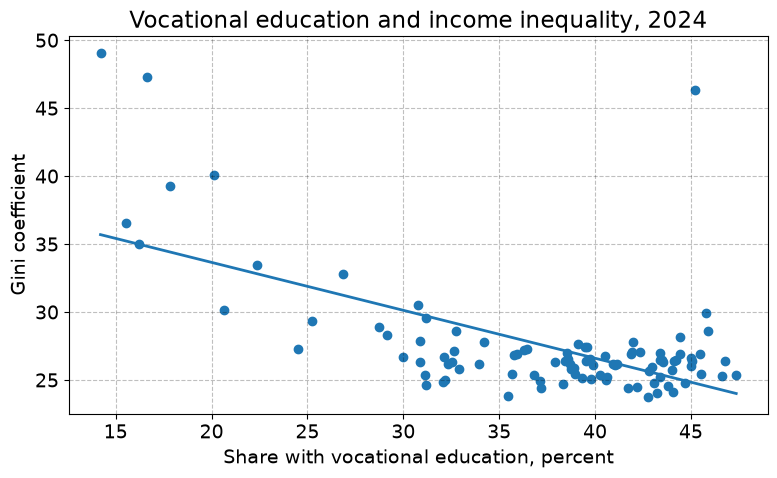

In [56]:
# p. plot vocational education share against Gini coefficient

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# a. scatter plot
ax.scatter(
    education_inequality['vocational'],
    education_inequality['gini']
)

# b. estimate linear trend
beta = np.polyfit(
    education_inequality['vocational'],
    education_inequality['gini'],
    1
)

# c. create values for fitted line
x = np.linspace(
    education_inequality['vocational'].min(),
    education_inequality['vocational'].max(),
    100
)

y_hat = beta[0] * x + beta[1]

# d. plot fitted line
ax.plot(
    x,
    y_hat,
    lw=2
)

# e. labels
ax.set_title('Vocational education and income inequality, 2024')
ax.set_xlabel('Share with vocational education, percent')
ax.set_ylabel('Gini coefficient')

fig.tight_layout()

#### Conclusion

The results suggest a clear relationship between educational attainment
and income inequality across municipalities in 2024. The share with a
Masters degree has the strongest positive correlation with the Gini
coefficient at 0.679, while the share with vocational education has the
strongest negative correlation at -0.607.

The scatter plots support these relationships, although a few
municipalities with very high Gini coefficients appear to influence the
pattern. The results should therefore be interpreted as correlations and
not as causal effects of education on inequality.

#### 1.4.2 Education profiles in high- and low-inequality municipalities

We compare the educational composition of the municipalities with the
highest and lowest Gini coefficients in 2024. In particular, we focus on
the shares of residents with Masters degrees and vocational education,
as these education categories showed the strongest positive and negative
correlations with the Gini coefficient.

In [57]:
# q. compare education in municipalities with high and low inequality

# a. select the 10 most unequal municipalities
high_gini = (
    education_inequality
    .nlargest(10, 'gini')
    [['municipality', 'gini', 'masters', 'vocational']]
    .copy()
)

# b. select the 10 least unequal municipalities
low_gini = (
    education_inequality
    .nsmallest(10, 'gini')
    [['municipality', 'gini', 'masters', 'vocational']]
    .copy()
)

# c. show results
print('Municipalities with highest Gini:')
print(high_gini)

print('')

print('Municipalities with lowest Gini:')
print(low_gini)

Municipalities with highest Gini:
      municipality   gini    masters  vocational
25        Gentofte  49.04  37.366068   14.206725
73       Rudersdal  47.31  35.043224   16.607130
92           Vejen  46.32   5.169340   45.226016
44        Hørsholm  40.07  29.572819   20.113805
56  Lyngby-Taarbæk  39.28  32.751540   17.850315
21   Frederiksberg  36.54  35.356560   15.528035
11      Copenhagen  34.97  30.880514   16.207967
2           Aarhus  33.43  23.455816   22.374153
19     Fredensborg  32.76  19.535385   26.874619
34       Helsingør  30.55  14.456319   30.765226

Municipalities with lowest Gini:
       municipality   gini    masters  vocational
15  Faaborg-Midtfyn  23.77   7.012399   42.772292
13           Egedal  23.85  14.570649   35.456645
8          Bornholm  24.03   6.611281   43.226065
18             Faxe  24.09   5.595901   44.065858
17         Favrskov  24.41  13.081909   37.187193
32          Halsnæs  24.41   7.050351   41.727185
5            Assens  24.46   6.690607   42.

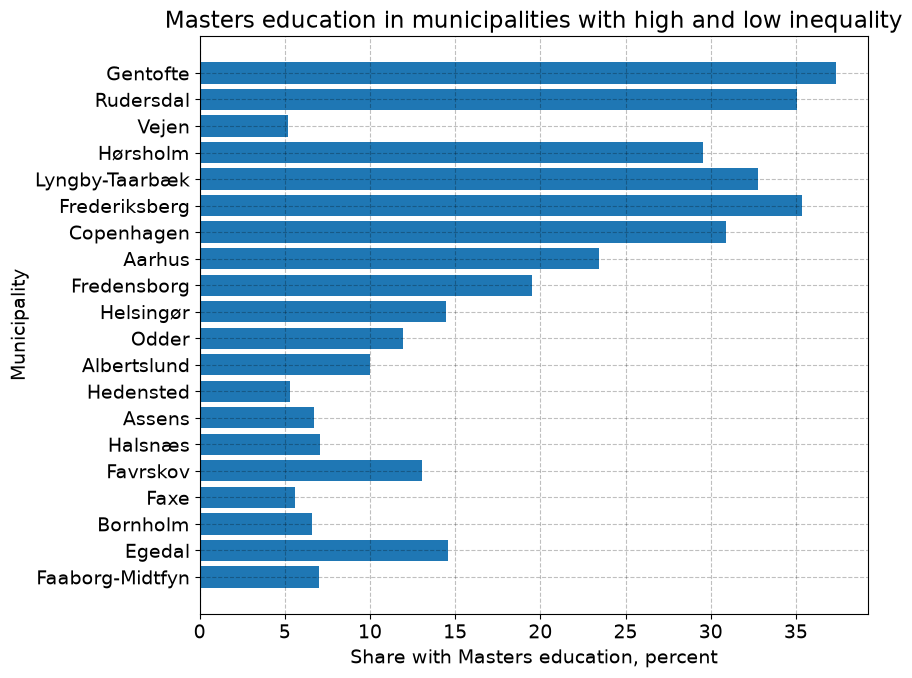

In [58]:
# r. illustrate Masters education in high- and low-Gini municipalities

# a. combine municipalities
education_ranking = pd.concat(
    [
        low_gini,
        high_gini
    ],
    ignore_index=True
)

# b. sort by Gini coefficient
education_ranking = (
    education_ranking
    .sort_values('gini')
    .reset_index(drop=True)
)

# c. create figure
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(1,1,1)

# d. horizontal bar chart
ax.barh(
    education_ranking['municipality'],
    education_ranking['masters']
)

# e. labels
ax.set_title(
    'Masters education in municipalities with high and low inequality'
)
ax.set_xlabel('Share with Masters education, percent')
ax.set_ylabel('Municipality')

fig.tight_layout()

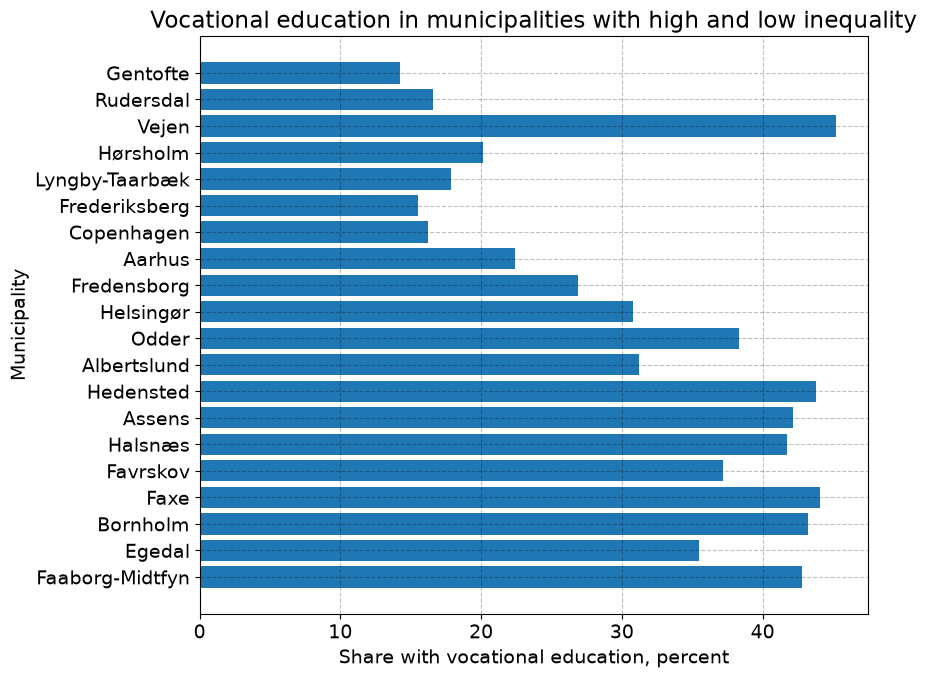

In [59]:
# s. illustrate vocational education in high- and low-Gini municipalities

# a. use the same municipalities as above
education_ranking = (
    education_ranking
    .sort_values('gini')
    .reset_index(drop=True)
)

# b. create figure
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(1,1,1)

# c. horizontal bar chart
ax.barh(
    education_ranking['municipality'],
    education_ranking['vocational']
)

# d. labels
ax.set_title(
    'Vocational education in municipalities with high and low inequality'
)
ax.set_xlabel('Share with vocational education, percent')
ax.set_ylabel('Municipality')

fig.tight_layout()

#### Conclusion

The results indicate that educational composition is related to differences
in income inequality across Danish municipalities in 2024. In particular,
the share of residents with a Masters degree is positively correlated with
the Gini coefficient (0.679), while the share with vocational education is
negatively correlated with the Gini coefficient (-0.607).

The municipality-level comparison is broadly consistent with these
correlations. Several municipalities with relatively high Gini coefficients,
such as Gentofte, Rudersdal, Hørsholm, Lyngby-Taarbæk and Frederiksberg,
also have relatively large shares of residents with Masters degrees and
relatively small shares with vocational education. Conversely, many of the
municipalities with low Gini coefficients have smaller Masters shares and
larger vocational education shares.

However, the relationship is far from uniform across municipalities. Vejen
is a particularly clear exception. Despite having one of the highest Gini
coefficients in 2024, it has a relatively low Masters share and a very high
vocational education share. As shown in the previous section, Vejen's high
Gini coefficient is largely associated with a sharp increase at the end of
the sample. This illustrates why individual municipalities and their
underlying Gini series should be considered before interpreting the overall
correlations.

More generally, educational composition should not be interpreted as a
causal explanation of municipal inequality. Municipalities differ along many
other dimensions that may be related to both education and income
inequality, including income levels, occupational structure, population
composition and the concentration of very high-income residents. The
analysis therefore only shows that certain education profiles tend to occur
together with higher or lower levels of measured inequality.

Overall, the results suggest that municipalities with a larger concentration
of highly educated residents tend to have higher measured income inequality,
while municipalities with a larger vocationally educated population tend to
have lower measured inequality. The relationship is nevertheless
heterogeneous across municipalities and should be interpreted as a
cross-sectional association rather than evidence that educational attainment
itself causes differences in inequality.

## 2. Simulating the income distribution

We simulate the income distribution using a simple life-cycle model.
Individuals differ in their education, employment histories and human
capital. The model is implemented in a separate Python module and
imported into the notebook.

### 2.1 The model

In [63]:
# a. import simulation model

from income_model import IncomeModelClass

In [64]:
# b. initialize model

model = IncomeModelClass(seed=1234)

# show selected parameters
print(f'Number of individuals: {model.N}')
print(f'Education probabilities: {model.p_education}')
print(f'Years of education: {model.years_education}')

Number of individuals: 50000
Education probabilities: [0.4  0.35 0.25]
Years of education: [1 3 5]


In [65]:
# c. draw education for all individuals

# a. draw education
model.draw_education()

# b. calculate simulated education shares
for i, education in enumerate(model.education_names):
    
    share = np.mean(model.education_index == i)
    
    print(
        f'{education}: '
        f'{100 * share:.2f} percent'
    )

short: 39.99 percent
medium: 35.17 percent
long: 24.85 percent


In [66]:
# d. set up life-cycle timing

# a. set up ages and labour-market entry
model.setup_life_cycle()

# b. show simulation period
print(f'First simulated age: {model.ages[0]}')
print(f'Last simulated age: {model.ages[-1]}')
print(f'Number of periods: {model.T}')

print('')

# c. show labour-market entry by education
for i, education in enumerate(model.education_names):

    I = model.education_index == i

    entry_age = model.labour_market_entry_age[I][0]

    print(
        f'{education}: '
        f'labour-market entry at age {entry_age}'
    )

First simulated age: 18
Last simulated age: 64
Number of periods: 47

short: labour-market entry at age 19
medium: labour-market entry at age 21
long: labour-market entry at age 23


In [67]:
# e. simulate employment histories

# a. simulate labour-market transitions
model.simulate_employment()

# b. calculate employment rate by age
employment_rate = np.mean(
    model.employed,
    axis=0
)

# c. show selected ages
for age in [19, 21, 23, 25, 30, 40, 50, 60]:

    t = age - model.age_start

    print(
        f'Age {age}: '
        f'employment rate = '
        f'{100 * employment_rate[t]:.2f} percent'
    )

Age 19: employment rate = 0.00 percent
Age 21: employment rate = 32.16 percent
Age 23: employment rate = 64.70 percent
Age 25: employment rate = 89.10 percent
Age 30: employment rate = 92.53 percent
Age 40: employment rate = 92.17 percent
Age 50: employment rate = 92.45 percent
Age 60: employment rate = 92.10 percent


In [68]:
# f. simulate human capital

# a. simulate human-capital paths
model.simulate_human_capital()

# b. calculate average human capital by age
mean_human_capital = np.mean(
    model.human_capital,
    axis=0
)

# c. show selected ages
for age in [18, 19, 21, 23, 30, 40, 50, 60]:

    t = age - model.age_start

    print(
        f'Age {age}: '
        f'mean human capital = '
        f'{mean_human_capital[t]:.3f}'
    )

Age 18: mean human capital = 1.207
Age 19: mean human capital = 1.207
Age 21: mean human capital = 1.199
Age 23: mean human capital = 1.198
Age 30: mean human capital = 1.304
Age 40: mean human capital = 1.508
Age 50: mean human capital = 1.752
Age 60: mean human capital = 2.040


In [69]:
# g. simulate income

# a. simulate income paths
model.simulate_income()

# b. calculate average income by age
mean_income = np.mean(
    model.income,
    axis=0
)

# c. show selected ages
for age in [18, 19, 21, 23, 25, 30, 40, 50, 60]:

    t = age - model.age_start

    print(
        f'Age {age}: '
        f'mean income = '
        f'{mean_income[t]:.3f}'
    )

Age 18: mean income = 0.450
Age 19: mean income = 0.410
Age 21: mean income = 0.587
Age 23: mean income = 0.842
Age 25: mean income = 1.147
Age 30: mean income = 1.274
Age 40: mean income = 1.472
Age 50: mean income = 1.712
Age 60: mean income = 1.991


In [70]:
# h. run complete simulation

# a. initialize model
model = IncomeModelClass(seed=1234)

# b. run simulation
model.simulate()

# c. show dimensions of simulated outcomes
print(f'Individuals: {model.N}')
print(f'Periods: {model.T}')
print(f'Employment matrix: {model.employed.shape}')
print(f'Human-capital matrix: {model.human_capital.shape}')
print(f'Income matrix: {model.income.shape}')

Individuals: 50000
Periods: 47
Employment matrix: (50000, 47)
Human-capital matrix: (50000, 47)
Income matrix: (50000, 47)


The model is implemented in `income_model.py`. The simulation follows
50,000 individuals from age 18 to 64. Education is drawn at age 18,
after which individuals enter the labour market at education-specific
ages. Employment evolves according to a two-state Markov process, while
human capital changes with employment status and stochastic shocks.
Income is determined by student grants, labour income or unemployment
benefits depending on the individual's state.

### 2.2 Simulate the income distribution

#### 2.2.1 Checking the simulation

Before analysing the simulated income distribution, we check that the
simulation reproduces two key properties of the model. First, the simulated
education shares should be close to the specified education probabilities.
Second, the unemployment rate should converge towards its theoretical
steady-state value.

In [71]:
# a. check simulated education shares

# a. calculate simulated shares
for i, education in enumerate(model.education_names):

    simulated_share = np.mean(
        model.education_index == i
    )

    target_share = model.p_education[i]

    print(
        f'{education}: '
        f'simulated = {100 * simulated_share:.2f} percent, '
        f'target = {100 * target_share:.2f} percent'
    )

short: simulated = 39.99 percent, target = 40.00 percent
medium: simulated = 35.17 percent, target = 35.00 percent
long: simulated = 24.85 percent, target = 25.00 percent


In [74]:
# b. check unemployment rate

# a. theoretical steady-state unemployment rate
steady_state_unemployment = (
    model.sigma_job
    / (model.sigma_job + model.lambda_job)
)

# b. initialize unemployment rate by age
unemployment_rate = np.full(
    model.T,
    np.nan
)

# c. calculate unemployment rate among labour-market participants
for t, age in enumerate(model.ages):

    # individuals who have entered the labour market
    active = (
        age >= model.labour_market_entry_age
    )

    # only calculate if someone is active
    if np.any(active):

        unemployment_rate[t] = np.mean(
            ~model.employed[active, t]
        )

# d. print theoretical value
print(
    f'Theoretical steady-state unemployment rate: '
    f'{100 * steady_state_unemployment:.2f} percent'
)

print('')

# e. show selected ages
for age in [19, 21, 23, 25, 30, 40, 50, 60]:

    t = age - model.age_start

    print(
        f'Age {age}: '
        f'unemployment rate = '
        f'{100 * unemployment_rate[t]:.2f} percent'
    )

Theoretical steady-state unemployment rate: 7.69 percent

Age 19: unemployment rate = 100.00 percent
Age 21: unemployment rate = 57.21 percent
Age 23: unemployment rate = 35.30 percent
Age 25: unemployment rate = 10.90 percent
Age 30: unemployment rate = 7.47 percent
Age 40: unemployment rate = 7.83 percent
Age 50: unemployment rate = 7.55 percent
Age 60: unemployment rate = 7.90 percent


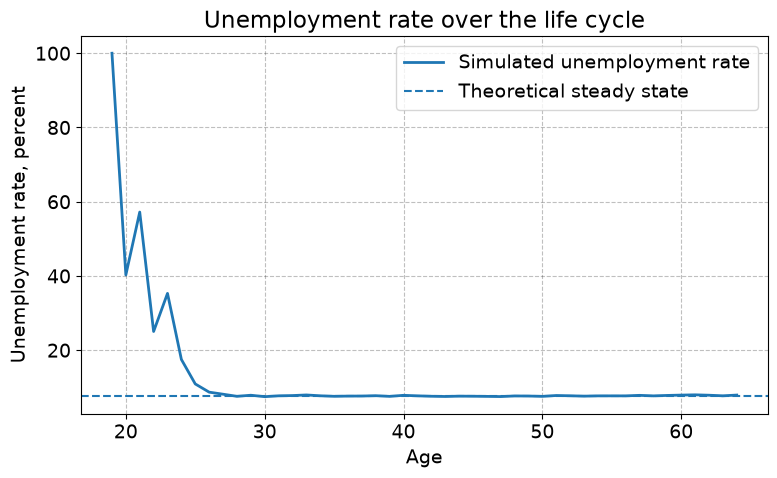

In [73]:
# c. plot unemployment rate over the life cycle

# a. create figure
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# b. simulated unemployment rate
ax.plot(
    model.ages,
    100 * unemployment_rate,
    lw=2,
    label='Simulated unemployment rate'
)

# c. theoretical steady-state unemployment rate
ax.axhline(
    100 * steady_state_unemployment,
    lw=1.5,
    ls='--',
    label='Theoretical steady state'
)

# d. labels
ax.set_title('Unemployment rate over the life cycle')
ax.set_xlabel('Age')
ax.set_ylabel('Unemployment rate, percent')

# e. legend
ax.legend()

fig.tight_layout()

The simulation reproduces the main properties of the model. The simulated
education shares are very close to the specified probabilities of 40, 35
and 25 percent.

The unemployment rate is initially high because individuals enter the labour
market as unemployed at different ages depending on their education. As the
cohort ages, the unemployment rate converges towards the theoretical
steady-state value of 7.69 percent. From around age 30 onwards, the simulated
unemployment rate fluctuates closely around this value. These checks suggest
that the simulation behaves as intended.

#### 2.2.2 Mean and percentiles of income over the life cycle


We examine how the simulated income distribution develops over the life
cycle by calculating the mean and selected percentiles of income at each age.

In [75]:
# d. calculate mean and percentiles of income

# a. calculate mean income by age
mean_income = np.mean(
    model.income,
    axis=0
)

# b. calculate selected percentiles by age
p10_income = np.percentile(
    model.income,
    10,
    axis=0
)

p25_income = np.percentile(
    model.income,
    25,
    axis=0
)

p50_income = np.percentile(
    model.income,
    50,
    axis=0
)

p75_income = np.percentile(
    model.income,
    75,
    axis=0
)

p90_income = np.percentile(
    model.income,
    90,
    axis=0
)

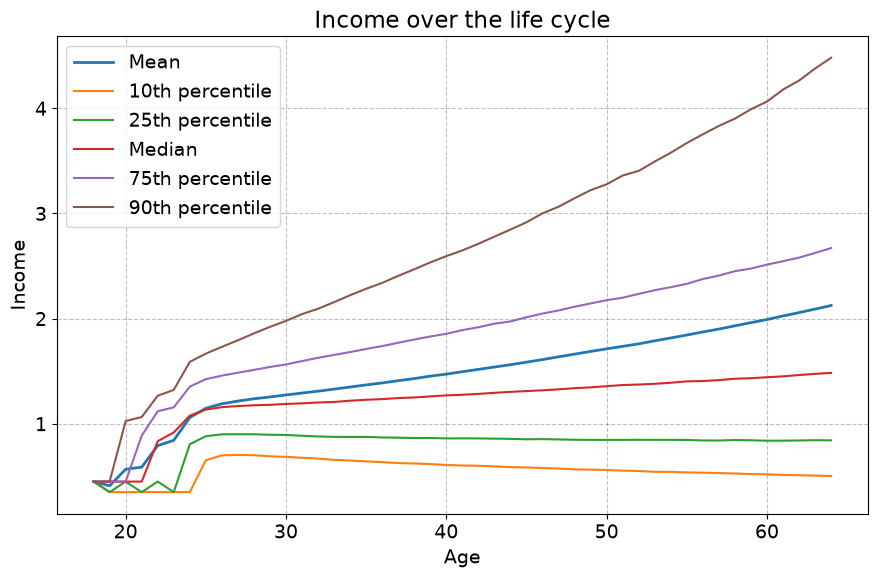

In [76]:
# e. plot mean and percentiles of income

# a. create figure
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(1,1,1)

# b. plot mean
ax.plot(
    model.ages,
    mean_income,
    lw=2,
    label='Mean'
)

# c. plot percentiles
ax.plot(
    model.ages,
    p10_income,
    lw=1.5,
    label='10th percentile'
)

ax.plot(
    model.ages,
    p25_income,
    lw=1.5,
    label='25th percentile'
)

ax.plot(
    model.ages,
    p50_income,
    lw=1.5,
    label='Median'
)

ax.plot(
    model.ages,
    p75_income,
    lw=1.5,
    label='75th percentile'
)

ax.plot(
    model.ages,
    p90_income,
    lw=1.5,
    label='90th percentile'
)

# d. labels
ax.set_title('Income over the life cycle')
ax.set_xlabel('Age')
ax.set_ylabel('Income')

# e. legend
ax.legend()

fig.tight_layout()

The income distribution becomes increasingly dispersed over the life cycle.
At young ages, incomes are relatively similar because individuals are either
in education or have only recently entered the labour market.

As individuals become older, the upper percentiles increase considerably.
The 90th percentile grows much faster than the median and the lower
percentiles. In contrast, the 10th and 25th percentiles remain relatively
low. This reflects differences in education, employment histories and the
accumulation of human capital.

The increasing distance between the lower and upper percentiles therefore
suggests that income dispersion increases over the life cycle in the
simulated model.

#### 2.2.3 Income distributions at selected ages

We examine the shape of the income distribution at ages 25, 35, 45
and 60 to see how the distribution changes over the life cycle.

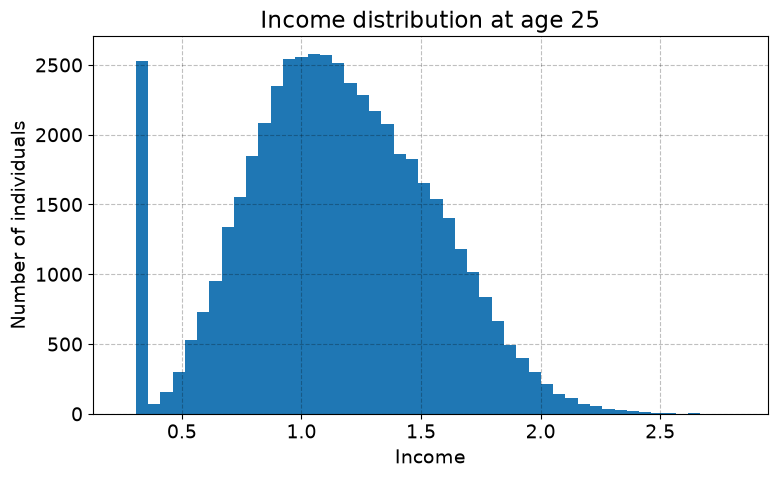

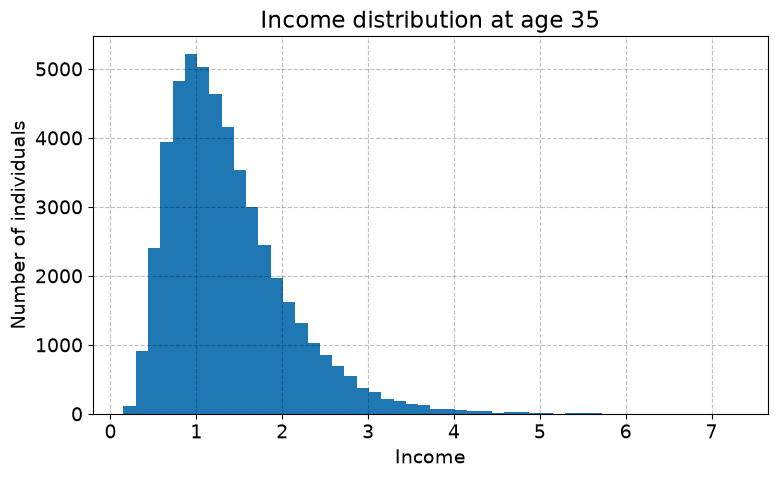

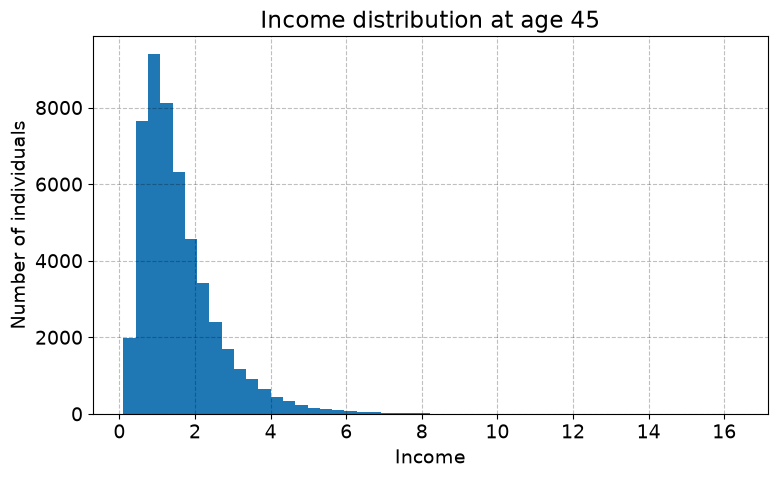

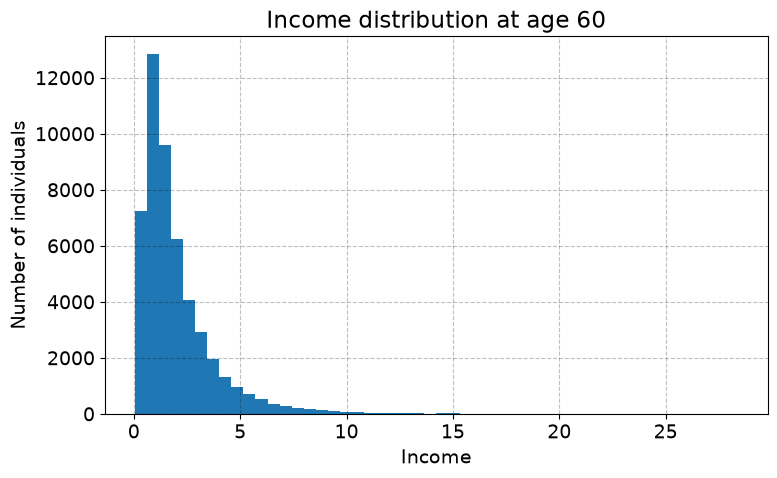

In [77]:
# f. plot income distributions at selected ages

# a. ages to examine
selected_ages = [25, 35, 45, 60]

# b. plot histogram for each age
for age in selected_ages:

    # i. find corresponding period
    t = age - model.age_start

    # ii. select income at given age
    income_age = model.income[:, t]

    # iii. create figure
    fig = plt.figure(figsize=(8,5))
    ax = fig.add_subplot(1,1,1)

    # iv. histogram
    ax.hist(
        income_age,
        bins=50
    )

    # v. labels
    ax.set_title(f'Income distribution at age {age}')
    ax.set_xlabel('Income')
    ax.set_ylabel('Number of individuals')

    fig.tight_layout()

#### Discussion

The shape of the income distribution changes substantially over the life
cycle. At age 25, the distribution is relatively concentrated, although it
is already somewhat right-skewed. There is also a distinct concentration at
low income, reflecting individuals who are unemployed and receive the
benefit floor or unemployment benefits.

As individuals become older, the income distribution becomes increasingly
right-skewed and dispersed. At ages 35 and 45, most individuals remain
concentrated at relatively moderate income levels, while an increasingly
long right tail develops.

By age 60, the right tail is considerably longer. A relatively small number
of individuals have very high incomes, while most individuals remain much
closer to the lower end of the distribution. This is consistent with the
accumulation of differences in human capital over time. Differences in
education, employment histories and repeated human-capital shocks compound
over the life cycle.

Overall, the simulation suggests that income inequality increases with age:
the typical part of the distribution moves upward, but the upper tail grows
considerably faster and becomes more dispersed.